# Why High Dimension Is Different


> **PHY 6937 / 4936 — Machine Learning in Physics.** Tutorial 02, notebook 1.
>
> **The series**<br>
> **1. Why high dimension is different**<br>
> **2. A search that works**<br>


---

We are going to explore an intuitive search algorithm that works
beautifully in two dimensions, and then discover that our intuition for *why* it
works is wrong — so wrong that the algorithm becomes useless long before we reach
the high-dimensional problems of this course.

In this notebook you'll explore a few of the ways in which **high-dimensional space is not shaped
the way you think it is.** The second notebook in this series explores a search algorithm more suited to high-dimensional spaces.

By the end of this notebook you will have verified three things in high-dimensional spaces:

1. almost all the volume of a ball sits in a paper-thin shell at its surface;
2. any two randomly chosen directions are almost always close to perpendicular;
3. the fraction of directions pointing usefully "downhill" diminishes
   *exponentially* with dimension.

And you will end on one sentence that determines every algorithmic choice in the
rest of the tutorial.

## A few Python/numpy constructs used throughout

| you will see | it means |
|---|---|
| `A @ B` | matrix multiplication (not element-by-element) |
| `A * B` | element-by-element multiplication |
| `v[2:5]` | the slice of `v` from index 2 up to *but not including* 5 |
| `arr.mean(axis=0)` | average down each column |
| `f = lambda t: t**2` | a one-line function; the same as `def f(t): return t**2` |
| `rng = np.random.default_rng(7)` | a random number generator seeded with 7, so results repeat exactly |

Run the cells **in order**. If you get a `NameError`, you almost certainly skipped one.

In [1]:
# ----------------------------------------------------------------------
# Imports. Run this cell first -- everything below depends on it.
# ----------------------------------------------------------------------
import numpy as np                 # arrays and linear algebra
import matplotlib.pyplot as plt    # plotting
from scipy.special import betainc  # incomplete beta function, used in Section 3

WIDTH = 6.0
HEIGHT= WIDTH*9/16
plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10.5, 
    "legend.frameon": False,
})

# Seeding the generator means you get the SAME "random" numbers every run,
# so your figures match the ones described in the text.
RNG = np.random.default_rng(20260828)
print("Ready. NumPy version:", np.__version__)

Ready. NumPy version: 2.3.5


# 1. The problem
Suppose you're given a function $f(x)$ that you can *evaluate* but not
differentiate, perhaps because it it too complicated — you put in a point, you get back a number, and that is all you can do with it. You want
to find the point $x$ where $f(x)$ is smallest. 

Today, we'll try to find the minimum of **Rosenbrock's** (https://en.wikipedia.org/wiki/Rosenbrock_function) function, which is coded in the next cell. This function is a standard benchmark for minimization studies. It contains a curved, narrow valley, its minimum value is exactly $0$ at the point where every
coordinate equals $1$, and it works in any number of dimensions.

In [2]:
def rosen(x):
    """Rosenbrock's function, valid in any number of dimensions."""
    # x[1:] is "everything from index 1 on"; x[:-1] is "everything but the last".
    # Pairing them compares each coordinate with the next.
    return float(np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2))

### 1.1 An algorithm you might have invented

You might propose the following:

> Given a point $p$, generate $m$ points on a sphere of radius $r$ around it.<br>
> Evaluate $f$ at all of them. Move to the best one. Shrink $r$. Repeat.

Which $m$ points? The natural choice is the $2n$ directions $\pm q_1, \ldots, \pm q_n$
— along an orthogonal set of axes, in both directions. This set has a property that **no matter
which way is downhill, at least one of these directions has a positive component
along the downhill direction.** (Such a set is called a *positive spanning set*; Torczon 1997 proved this
is what makes the method work.) Since nothing about the problem requires a particular orientation of the axes, we'll rotate the axes randomly at each step.

---
#### Note 1: Rotation Matrices

Consider a vector $x \in \mathbb{R}^n$, that is, $n$-dimensional Euclidean space. An $n \times n$ rotation matrix, $Q$, has the property that it leaves the norm (that is, magnitude), $\| x \|$, of a vector unchanged. Let's rotate the vector $x$ using $y = Q x$. By definition, the square of the norm of the rotated vector $y$ is given by $\|y\|^2 = y^T y$. Therefore, $\|y\|^2 = (Q x)^T Q x$ implies $\|y\|^2 = x^T Q^T Q x$. If $\|y\|^2$ is to equal $\|x\|^2 = x^T x$, then $Q$ must be **orthogonal**, that is, $Q^T Q = \mathbb{I}$. In addition, to be a rotation matrix $\det Q = +1$.

We can create a random rotation matrix $Q$ from another matrix, $A$, of shape $(n, n)$ that is filled with random numbers. Suppose that $a_1,\cdots, a_n$ are the columns  of $A$ interpreted as vectors in $\mathbb{R}^n$. Then $A$ can be decomposed as follows
$$A = Q R,$$
where $Q$ is an orthogonal matrix with determinant $+1$ and $R$ is an upper triangular matrix. These matrices can be written as
\begin{align}
Q & = \begin{pmatrix} q_1 & \cdots & q_n \end{pmatrix},\\
R & = \begin{pmatrix}
        a_1 \cdot q_1 & a_2 \cdot q_1 & \cdots & a_n \cdot q_1\\
        0             & a_2 \cdot q_2 & \cdots & a_n \cdot q_2\\
        \vdots & \vdots\\
        0 & 0 & \cdots & a_n \cdot q_n
    \end{pmatrix},
\end{align}
where $q_i$ are orthonormal column vectors created via **Gram-Schmidt orthogonalization** from the vectors $a_i$. Given a matrix $A$, modeled as a numpy array of shape $(n, n)$, the function `np.linalg.qr` returns the matrices $Q$ and $R$. See, however, Note 2 below.

**A tiny bit of group theory** The set of all $(n, n)$ orthogonal matrices constitute  a group called the **orthogonal group**, denoted by the symbol $O(n)$. This group splits into two disjoint pieces: one for matrices with determinant $-1$ (that model reflections) and the other for matrices with determinant $+1$ that rotate vectors in $n$-dimensional Euclidean space. Only the second piece is itself a sub-group: the reflections do not include the identity, and the product of two reflections is a rotation, so the reflections are not closed under multiplication. (In the language of group theory they form a *coset* of the rotations.) That sub-group, which mathematicians call the **special orthogonal group** denoted by the symbol $SO(n)$, is the group from which we want to randomly, and uniformly, sample rotation matrices for our search algorithm as we move from one point to the next. 

---
#### Note 2: Why the sign correction in `random_rotation`

Note 1 built $Q$ by Gram–Schmidt where the diagonal of $R$ is automatically
**positive**: $r_{ii} = a_i \cdot q_i$ > 0. 

But the decomposition of $A$ is **not unique**. Let $S = \mathrm{diag}(s_1,\dots,s_n)$ with every
$s_i = \pm 1$. Then $S^2 = \mathbb{I}$, so

$$A \;=\; QR \;=\; (QS)(SR),$$

and $QS$ is still orthogonal while $SR$ is still upper triangular. So $(QS, SR)$ is an
equally valid QR decomposition of the same $A$. There are $2^n$ decompositions, and exactly one
has all $r_{ii} > 0$ — the Gram–Schmidt one of Note 1.

`np.linalg.qr` does **not** use Gram–Schmidt. It calls the linear algebra package LAPACK, which uses another method called Householder
reflections, and that returns one of the *other* decompositions. The consequence is that the random sampling of $Q$ over $O(n)$ is not uniform. This yields two symptoms (both investigated in the Appendix):

- **$\det Q$ is not random.** LAPACK's $Q$ comes back with $\det Q = (-1)^{n-1}$ on
  *every single draw*. A uniformly selected random orthogonal matrix is a rotation
  ($\det = +1$) or a reflection ($\det = -1$) with equal probability. This not what happens with LAPACK even when the entries in $A$ are random. For even $n$, the matrix returned by 
  `np.linalg.qr` is always a reflection.
- **The diagonal of $Q$ is biased.** For uniformly, and randomly, sampled orthogonal matrices one expects
  $E[Q_{ii}] = 0$, however, LAPACK gives $|E[Q_{ii}]| \approx 0.32$ to $0.38$.

We fix these problems with the line `q * np.sign(np.diag(r))` in `random_rotation`, which multiplies **column** $i$ of $Q$ by $\mathrm{sign}(r_{ii})$
— a 1-D array broadcasts across rows, so it scales columns, not rows. That is exactly the
$Q \to QS$ above with $s_i = \mathrm{sign}(r_{ii})$, which renders all $r_{ii} > 0$ and so
selects the Gram–Schmidt factorization. Uniform sampling **over $O(n)$** is thereby restored
(Mezzadri 2007).

**A second step is needed to reach $SO(n)$.** The sign correction fixes the *distribution*,
but a uniform draw from $O(n)$ is a rotation or a reflection with probability one half each —
so $\det Q = -1$ half the time, and $Q$ is then not a rotation at all. Since Note 1 asks for
$SO(n)$, `random_rotation` finishes the job by negating one column whenever $\det Q < 0$.
Negating a column flips the sign of the determinant, and it maps the reflection coset onto
$SO(n)$ one-to-one, so the result is still *uniform* — now over the rotations. A good check
is that the mean of $\det Q$ over many draws goes from $\approx 0$ (an equal mix of $\pm 1$)
to exactly $1$.

**One honest caveat.** For *this* notebook the correction changes nothing, and it is worth
seeing why. `poll_directions` uses the columns $q_1, \dots, q_n$ of $Q$ to build the set
$\{\pm q_1, \dots, \pm q_n\}$. Flipping the sign of a column sends $q_i \to -q_i$, which
maps that set **onto itself** — the poll directions come out identical either way, as the
last line of the demonstration in the Appendix checks. Neither correction is included because our problem needs it; both are here for
pedagogical clarity, because together they are the right way to draw a random rotation. 

*Reference:* F. Mezzadri, "How to Generate Random Matrices from the Classical Compact
Groups," *Notices of the AMS* **54**(5), 592–604 (2007),
[arXiv:math-ph/0609050](https://arxiv.org/abs/math-ph/0609050).

In [3]:
def random_rotation(n, rng):
    """Return a random n-by-n orthogonal matrix with unit determinant, uniformly 
    distributed.

    Algorithm:
    Take a matrix A of random Gaussian-distributed numbers and QR-decompose it. 
    Construct a diagonal matrix S, which when applied to R renders all diagonal
    elements of R positive. Apply S to Q, thereby creating a random rotation
    matrix such that over a large ensemble of draws the matrices Q are uniformly
    sampled from the group SO(n). See Note 2 above.

    np.sign(np.diag(r)) is a 1-D array, so multiplying broadcasts across rows,
    i.e. it rescales the COLUMNS of q. That forces every r_ii > 0 and so picks
    out the Gram-Schmidt factorization of Note 1.

    That step alone samples uniformly from O(n), which is a reflection half the
    time. The final two lines negate one column whenever det Q < 0, which maps
    the reflections one-to-one onto the rotations and so leaves the sampling
    uniform -- now over SO(n), as Note 1 asks for.
    """
    A = rng.standard_normal((n, n)) # random matrix
    Q, R = np.linalg.qr(A)          # decompose
    S = np.sign(np.diag(R))         # diagonal correction matrix
    Q = Q * S                       # now uniform over O(n)
    if np.linalg.det(Q) < 0:        # discard the reflection ...
        Q[:, 0] = -Q[:, 0]          # ... by flipping one column
    return Q                        # now uniform over SO(n)

In [4]:
N = 25_000
n = 3
detQ = []
for i in range(N):
    Q = random_rotation(n, RNG)
    detQ.append(np.linalg.det(Q))
detQ = np.array(detQ)
detQ.mean()

np.float64(1.0)

In [5]:
def poll_directions(n, rng):
    """The 2n directions +-q_i, randomly rotated. Returns a (2n, n) array.

    np.eye(n) is the identity matrix, whose rows are e_1 ... e_n. Stacking it on
    top of MINUS itself gives all 2n axis directions. Then we rotate them.
    """
    return np.vstack((np.eye(n), -np.eye(n))) @ random_rotation(n, rng).T

**Try to understand each line in the function `poll_search` below**.

In [6]:
def poll_search(f, x0, r=0.5, r_min=1e-9, max_nfev=200_000, ftarget=None, seed=0):
    """Minimize f by polling m = 2n points on a sphere of radius r.

    The sphere's radius is driven by SUCCESS, not by a fixed schedule. 
    The radius grows after a successful step but shrinks if a poll fails.

    Arguments:
    f        : function to be minimized
    x0       : starting point
    r        : radius of sphere in n dimensional Euclidean space
    r_min    : minimum radius of sphere
    max_nfev : maximum number of function evaluations
    ftarget  : stop early once f drops below this
    
    seed     : random number generator seed

    Returns:
    hist     : list of 4-tuples: (x, fx, r, nfev)
    
              x:    center of sphere
              fx:   value of function at x
              r:    radius of sphere
              nfev: number of function evaluations
    y0       : first set of poll points
    """
    rng = np.random.default_rng(seed)

    x   = np.array(x0, float)     # starting point of search
    n   = x.size                  # the dimension of vector
    fx  = f(x)                    # function value at x
    nfev= 1                       # number of times f has been evaluated
    hist= [(x, fx, r, nfev)]      # history of search (list of points)
    
    while nfev < max_nfev:

        d = poll_directions(n, rng)           # STEP 1a: construct 2n othogonal directions
        
        Y = x + r * d                         # STEP 1b: constuct the 2n points, Y, on the n-sphere
                                              #   (x is broadcast across every row)
        if nfev == 1:                         
            y0 = Y                            # save initial poll points
            
        fY = np.array([f(y) for y in Y])      # STEP 2: evaluate f at all 2n points
        nfev += len(Y)                        # update number of function evaluations                  
        
        k = int(np.argmin(fY))                # STEP 3: which of the 2n points has the smallest f(x)?

        if fY[k] < fx:                        # STEP 4: move there if it improved
            x, fx = Y[k], float(fY[k])
            r *= 2.0                          #   success -> next time reach further
        else:
            r *= 0.5                          #   failure -> next time look closer

        hist.append((x, fx, r, nfev)) 

        if ftarget is not None and fx < ftarget:
            break

        if r < r_min:
            break

    return hist, y0

### 1.2 Run `poll_search` on function `rosen`

In [7]:
X0   = np.array([-0.5, 1.5])   # starting point
R0   = 0.4                     # starting radius
RMIN = 1e-6                    # final radius

hist, y0 = poll_search(rosen, X0, r=R0, r_min=RMIN, max_nfev=8000)

print(f'Number of points along search path: {len(hist)}')

Number of points along search path: 1438


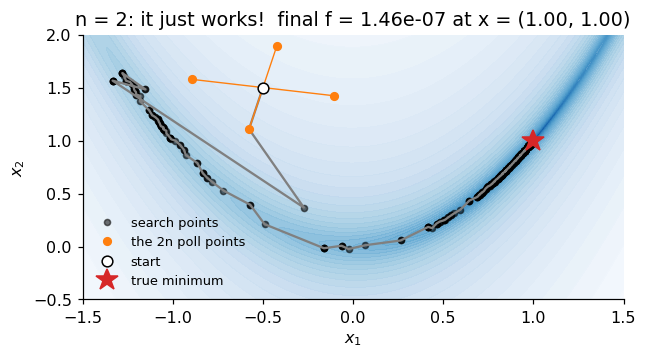

In [8]:
def plot_search_path(hist, wheel):

    # draw contour map of Rosenbrock function
    gx, gy = np.meshgrid(np.linspace(-1.5, 1.5, 400), np.linspace(-0.5, 2.0, 400))
    gz = 100*(gy - gx**2)**2 + (1 - gx)**2       # Rosenbrock over the whole grid
    
    fig, ax = plt.subplots()
    ax.contourf(gx, gy, np.log10(gz + 1e-3), levels=40, cmap="Blues_r", alpha=.85)
    
    # draw array of search points and join them with a line
    P = np.array([p[0] for p in hist])
    ax.plot(P[:, 0], P[:, 1], ".", ms=8.0, color='black', alpha=.55,
            label="search points")
    ax.plot(P[:, 0], P[:, 1], color='grey')
    
    # draw the axes at the starting point
    x0, fx, r, nfev = hist[0]                     # get starting point
    for w in wheel:
        ax.plot([x0[0], w[0]], [x0[1], w[1]], "-", lw=.9, color="#ff7f0e")

    # draw the 2n poll points around the starting point
    ax.plot(wheel[:, 0], wheel[:, 1], "o", ms=5, color="#ff7f0e",
            label="the 2n poll points")

    # draw the starting point
    ax.plot(*x0, "o", ms=7, color="white", mec="black", label="start")

    # draw the true end point
    ax.plot(1, 1, "*", ms=15, color="#d62728", label="true minimum")

    xf, fx, r, _ = hist[-1]                     # get final point
    ax.set(xlabel="$x_1$", ylabel="$x_2$",
           title=f"n = 2: it just works!  final f = {fx:.2e} at x = ({xf[0]:4.2f}, {xf[1]:4.2f})")
    ax.legend(loc="lower left", fontsize=8.5); ax.grid(False)
    
    plt.tight_layout()
    plt.show()

plot_search_path(hist, y0)

Four evaluations per iteration, a visible wheel of trial points, a sensible walk down
the valley. Everything about this picture says *of course it works*.

**And that is the problem.** Nothing in it warns you about what happens at $n = 200$ dimensions. Our intuition is trained on two and three dimensions, but for high dimensions our intuition is totally misleading! The next section shows how.

---
## 2. Navigating high dimensions

-  **Almost all the volume of a ball sits just under its skin.** The volume of a ball of radius $R$ in $n$ dimensions is proportional to $R^n$. So the
fraction of the volume *inside* radius $(1-\varepsilon)R$ is $(1-\varepsilon)^n$. In high dimension, sampling inside a ball and sampling on its surface are
effectively the same thing.
-  **Every pair of random directions is almost perpendicular.** Pick any two directions at *random*. In two dimensions the angle between them is uniform:
any angle is as likely as any other. In high dimension this is dramatically false.

Suppose the true downhill direction is $g$. We ask two
*different* questions:

- **How much of $g$, on average, does one random direction capture?** That is the average of
  $|\cos\theta|$. 
  
- **How likely is a random direction to be aligned within $60°$
  of $g$**? That is the fractional area of a spherical cap of a sphere in $n$ dimensions.  

You'll explore these claims and questions below in **Exercise 1**. 

## Exercise 1

For dimensions $n = 2, 3, 10, 50, 100, 200, 400$ answer the following questions by coding the required computations. 

*Hints*: the functions `random_directions` and `cap_fraction` will be useful.

To print results out tidily, try

In [9]:
print(f"{'n':>10s} {'n^(5/2)':>10s}")   # outer quotes doubled: works on Python < 3.12 too
for n in [2,3,5,10]:
    print(f'{n:>10d} {n**(5/2):>10.5f}')

         n    n^(5/2)
         2    5.65685
         3   15.58846
         5   55.90170
        10  316.22777


In [22]:
def random_directions(m, n, rng):
    """Return m uniformly random unit vectors in n dimensions, as an (m, n) array.
    Each vector is modeled as a row in the array.
    
    Marsaglia's method (1972): draw n independent Gaussians and divide by the
    vector's length. Since the multivariate Gaussian is spherically symmetric,
    the resulting vectors point in a perfectly uniform random direction.

    norm_u = np.linalg.norm(u, axis=1, keepdims=True) is the length of EACH ROW;
    keepdims=True preserves the number of dimensions of u so the shape of
    norm_u will be (m, 1) rather than (m, ). That way division by norm_u 
    broadcasts across columns. The single column of norm_u is effectively 
    replicated columnwise to form an array of shape (m, n) whereupon the
    division u / norm_u is done elementwise. 
    """
    u = rng.standard_normal((m, n))                   # u.shape = (m, n)
    norm_u = np.linalg.norm(u, axis=1, keepdims=True) # norm_u.shape = (m, 1)
    return u / norm_u # elementwise division after broadcasting

def cap_fraction(n, theta):
    """Exact fractional area of a spherical cap of angular radius theta <= pi/2."""
    return 0.5 * betainc((n - 1) / 2, 0.5, np.sin(theta)**2)
# ---------------------------------------------------------------------------------
DIMS = [2, 3, 10, 50, 200, 400]
NUM_VEC = 50_000

**Answer the following questions**. Where appropriate do this for every $n$ in `DIMS`.

  1. What fraction of the volume of a sphere in $n$ dimensions lies within 2\% of its surface, that is, within the shell of inner and outer radii $(1-\epsilon)R$ and $R$, respectively?

In [23]:
print(f"{'n':>10s} {'percentage':>10s}")   # outer quotes doubled: works on Python < 3.12 too

epsilon = 0.02
for n in DIMS:
    f = (1 - (1 - epsilon)**n)*100
    print(f'{n:>10d} {f:>10.4f}')

         n percentage
         2     3.9600
         3     5.8808
        10    18.2927
        50    63.5830
       200    98.2412
       400    99.9691


  2. What is the average absolute cosine of the angle between any two randomly chosen unit vectors? $m$ random directly $n$-dimensional unit vectors can be generated using `random_directions(m, n, rnd)` below. *Hint*: if `a` and `b` are arrays of unit vectors, of shape $(m, n)$, an array of $|\cos\theta|$ of shape $(m, )$ can be computed using
     `abscos = np.abs(np.sum(a * b, axis=1))`. Average over `m = NUM_VEC = 50_000` pairs of randomly chosen unit vectors.

In [24]:
A = random_directions(5, 3, RNG)
B = random_directions(5, 3, RNG)
AB = A*B
AdotB = AB.sum(axis=1)
A, B, AB, AdotB, np.acos(AdotB)

(array([[-0.6057797 ,  0.4096901 ,  0.6820447 ],
        [ 0.0478502 , -0.14063207,  0.98890494],
        [-0.1747646 ,  0.98100751,  0.08415228],
        [-0.51616369,  0.73725392, -0.43592627],
        [-0.89972871,  0.3945631 , -0.18656956]]),
 array([[-0.12938837, -0.94184801,  0.31013058],
        [-0.69701013, -0.60677969,  0.38209329],
        [-0.56237798,  0.48401907, -0.6704152 ],
        [ 0.04011978, -0.73827349,  0.67330725],
        [ 0.91730092,  0.22288969, -0.32996851]]),
 array([[ 0.07838085, -0.3858658 ,  0.21152292],
        [-0.03335208,  0.08533269,  0.37785394],
        [ 0.09828376,  0.47482635, -0.05641697],
        [-0.02070838, -0.54429502, -0.29351232],
        [-0.82532197,  0.08794405,  0.06156208]]),
 array([-0.09596204,  0.42983455,  0.51669314, -0.85851571, -0.67581585]),
 array([1.66690626, 1.1264868 , 1.02781228, 2.6031644 , 2.31286735]))

In [26]:
print(f"{'n':>10s} {'percentage':>20s}")   # outer quotes doubled: works on Python < 3.12 too

m = NUM_VEC # number of pairs of randomly oriented unit vectors.

for n in DIMS:
    a = random_directions(m, n, RNG)
    b = random_directions(m, n, RNG)

    abscos = np.abs(np.sum(a * b, axis=1))
    angle  = np.acos(abscos)
    angle_deg = np.rad2deg(angle)
    
    angle_mean = angle_deg.mean()
    angle_std  = angle_deg.std()
    
    print(f'{n:>10d} {angle_mean:>10.2f}, {angle_std:>10.2f}')

         n           percentage
         2      44.98,      25.96
         3      57.46,      21.51
        10      74.62,      11.36
        50      83.46,       4.95
       200      86.77,       2.45
       400      87.71,       1.73


 3. At what
dimension $n$ does the fraction of directions that lie within $60°$ of downhill first drop
below $10^{-6}$? This fraction is given by
$\tfrac12 I_{\sin^2\theta}\!\left(\tfrac{n-1}{2}, \tfrac12\right)$ for angle $\theta \le \pi/2$, where $I$ is the
regularized incomplete beta function — `scipy.special.betainc`. The fraction can be computed using the `cap_fraction(n, theta)` below with `theta` in radians.

In [28]:
f = 1.0
n = 1
max_n = 1_000_000
while (n < max_n) and (f > 1.e-6):
    n += 1
    f = cap_fraction(n, np.pi / 3)
    
print(f'{n:>10d} {f:>10.4e}')

        81 8.6460e-07


  4. How many random directions would you have to sample,
on average, to find one such direction at $n = 400$.

  5. At one microsecond per try, how long that would take to find a good direction?

---

## Where we are, and what is next

You have established that the geometry of high-dimensional space defeats the obvious
search strategy. 

> ### Here is the key sentence to remember 
> **In high dimension you do not make progress by *finding* a good direction — there
> are far too few to find. You make progress by *accepting a mediocre direction and
> taking many steps*.**

Notebook 2 turns that sentence into an algorithm, and measures how much it wins by.


## References for this notebook

- G. Marsaglia, "Choosing a Point from the Surface of a Sphere," *Annals of
  Mathematical Statistics* **43**(2), 645–646 (1972).
  [doi:10.1214/aoms/1177692644](https://doi.org/10.1214/aoms/1177692644) — the
  method used by `random_unit`.
- R. Vershynin, *High-Dimensional Probability: An Introduction with Applications in
  Data Science.* Cambridge University Press, 2018, ISBN 9781108415194 — concentration
  of measure, the mathematics behind Section 2. (2nd edition 2026.)
- V. Torczon, "On the Convergence of Pattern Search Algorithms," *SIAM Journal on
  Optimization* **7**(1), 1–25 (1997).
  [doi:10.1137/S1052623493250780](https://doi.org/10.1137/S1052623493250780) — why
  the poll directions must positively span the space.

*Added for Appendix B:*

- Archimedes, *On the Sphere and Cylinder* (c. 225 BC) — the $n=3$ case; the sphere
  inscribed in a cylinder that he asked for on his tombstone.
- R. A. Fisher, "Frequency distribution of the values of the correlation coefficient in
  samples from an indefinitely large population," *Biometrika* **10**(4), 507–521 (1915)
  — the same density, derived by $n$-dimensional geometry, as the null distribution of $r$.
- É. Borel, *Introduction géométrique à quelques théories physiques.* Gauthier-Villars,
  Paris, 1914 — the earliest known statement that the coordinates of a random point on a
  high-dimensional sphere are asymptotically Gaussian.
- P. Diaconis and D. Freedman, "A dozen de Finetti-style results in search of a theory,"
  *Annales de l'I.H.P. Probabilités et Statistiques* **23**(S2), 397–423 (1987)
  — traces the attribution and reports being unable to find the result in Poincaré.

## Appendix

**Would `scipy` be any different in terms of generating othogonal matrices?** No. `scipy.linalg.qr` calls the same LAPACK
routine as `np.linalg.qr` and returns the same factorization, with the same sign
convention and the same bias — the demonstration below checks this explicitly rather
than asking you to take it on faith. (`scipy` does ship a correctly distributed
generator, `scipy.stats.ortho_group`, whose documentation cites the same Mezzadri
paper; we stay with `numpy` here so that the correction is visible rather than hidden
inside a library call.)

In [11]:
# ---------------------------------------------------------------------------
# Demonstration of Note 2. Draw many matrices both ways and compare.
# (A digression -- nothing later in the notebook depends on this cell.)
# ---------------------------------------------------------------------------
import scipy.linalg          # only to show it behaves identically

n, K = 5, 20_000
rng_demo = np.random.default_rng(1)

raw   = np.zeros((K, n, n))      # Q exactly as np.linalg.qr returns it
fixed = np.zeros((K, n, n))      # Q after the sign correction
for k in range(K):
    q, r = np.linalg.qr(rng_demo.standard_normal((n, n)))
    raw[k]   = q
    fixed[k] = q * np.sign(np.diag(r))          # <-- the correction

d = np.arange(n)                                # index the diagonal entries
print(f"n = {n}, {K:,} draws\n")
print("mean of the diagonal entries of Q      (uniform would give 0):")
print("   np.linalg.qr as-is :", np.round(raw[:,   d, d].mean(axis=0), 3))
print("   sign-corrected     :", np.round(fixed[:, d, d].mean(axis=0), 3))

# the second step: negate a column wherever the determinant is negative
so_n = fixed.copy()
so_n[np.linalg.det(so_n) < 0, :, 0] *= -1

print("\nfraction of draws with det Q = +1      (uniform over O(n) gives 0.5):")
print(f"   np.linalg.qr as-is : {(np.linalg.det(raw)   > 0).mean():.3f}")
print(f"   sign-corrected     : {(np.linalg.det(fixed) > 0).mean():.3f}")
print(f"   + det<0 col flip   : {(np.linalg.det(so_n)  > 0).mean():.3f}"
      f"   <- what random_rotation returns (SO(n))")
print(f"\nmean of det Q for random_rotation      : "
      f"{np.linalg.det(so_n).mean():.6f}   (a mix of +-1 would give ~0)")

print("\ndet of the RAW Q, dimension by dimension -- the pattern is (-1)^(n-1):")
for m in (2, 3, 4, 5, 6):
    q, _ = np.linalg.qr(rng_demo.standard_normal((m, m)))
    print(f"   n = {m}:  det Q = {np.linalg.det(q):+.0f}"
          f"   ({'reflection' if np.linalg.det(q) < 0 else 'rotation'}, every time)")

# Is scipy any different? Feed both the SAME matrix and compare.
A = rng_demo.standard_normal((n, n))
qn, rn = np.linalg.qr(A)
qs, rs = scipy.linalg.qr(A)
print(f"\nnumpy vs scipy on the same matrix:  max|Q_np - Q_sp| = "
      f"{np.abs(qn - qs).max():.1e},  max|R_np - R_sp| = {np.abs(rn - rs).max():.1e}")
print("   (identical -- both call the same LAPACK routine, so scipy has the same bias)")

# ...and the caveat: it makes no difference to the SET of poll directions.
m = 4
q, r = np.linalg.qr(rng_demo.standard_normal((m, m)))
as_set = lambda Q: np.array(sorted(map(tuple, np.round(
    np.vstack((np.eye(m), -np.eye(m))) @ Q.T, 10).tolist())))
print(f"\nSame SET of 2n poll directions either way?  "
      f"{np.allclose(as_set(q), as_set(q * np.sign(np.diag(r))))}")

n = 5, 20,000 draws

mean of the diagonal entries of Q      (uniform would give 0):
   np.linalg.qr as-is : [-0.375 -0.357 -0.341 -0.324  0.327]
   sign-corrected     : [-0.003 -0.001 -0.006 -0.    -0.002]

fraction of draws with det Q = +1      (uniform over O(n) gives 0.5):
   np.linalg.qr as-is : 1.000
   sign-corrected     : 0.498
   + det<0 col flip   : 1.000   <- what random_rotation returns (SO(n))

mean of det Q for random_rotation      : 1.000000   (a mix of +-1 would give ~0)

det of the RAW Q, dimension by dimension -- the pattern is (-1)^(n-1):
   n = 2:  det Q = -1   (reflection, every time)
   n = 3:  det Q = +1   (rotation, every time)
   n = 4:  det Q = -1   (reflection, every time)
   n = 5:  det Q = +1   (rotation, every time)
   n = 6:  det Q = -1   (reflection, every time)

numpy vs scipy on the same matrix:  max|Q_np - Q_sp| = 0.0e+00,  max|R_np - R_sp| = 0.0e+00
   (identical -- both call the same LAPACK routine, so scipy has the same bias)

Same SET of 2n poll di

---
### Appendix B: the exact distribution of $\cos\theta$

In Section 2 we *measured* the distribution of $\cos\theta$ between two random directions
and quoted $E|\cos\theta| \approx \sqrt{2/\pi n}$. Both the histogram and that average have
exact closed forms, and getting them is a nice lesson in how a frightening integral can
collapse.

The thing you would write down is

$$p(t) \;=\; \int d^n\!x\; d^n\!y\;\;
\delta\!\left(t - \frac{x\cdot y}{\|x\|\,\|y\|}\right)\,
g(x_1)\cdots g(x_n)\, g(y_1)\cdots g(y_n),$$

with $g$ the standard Gaussian. That is a $2n$-dimensional integral — at $n=200$, four
hundred nested integrations. It looks hopeless. It is not: **three observations reduce it
to one dimension.**

#### Step 1 — the lengths are irrelevant

Write $x = r\,\hat u$ with $\hat u$ a unit vector. The Gaussian is *rotationally
invariant*, so its measure factorizes into a radial part and a uniform part on the sphere.
The $\delta$ depends only on $\hat u\cdot\hat v$ — the radii appear nowhere. So both radial
integrals separate off and integrate to $1$, leaving

$$p(t) \;=\; \int_{S^{n-1}}\!\!\int_{S^{n-1}} d\bar\sigma(\hat u)\,d\bar\sigma(\hat v)\;
\delta(t - \hat u\cdot\hat v),$$

where $d\bar\sigma$ is the *normalized* surface measure. Notice what this says: **the
Gaussian was never essential.** Any rotationally invariant density would have given the
same answer. This is a fact about the sphere, not about $g$.

#### Step 2 — one of the two sphere integrals is free

The inner integral over $\hat u$ is unchanged if we rotate everything so that
$\hat v = e_1$. Doing so, the outer integral just integrates a constant over a normalized
measure, giving $1$:

$$p(t) \;=\; \int_{S^{n-1}} d\bar\sigma(\hat u)\;\delta(t - \hat u_1).$$

So $p(t)$ is simply **the density of one coordinate of a uniformly random point on the
sphere.** We have gone from $2n$ dimensions to one.

#### Step 3 — that marginal is elementary

Two derivations, pick whichever you prefer.

*Geometric.* The set of points on $S^{n-1}$ with first coordinate equal to $t$ is a sphere
$S^{n-2}$ of radius $\sqrt{1-t^2}$, whose area $\propto (1-t^2)^{(n-2)/2}$. A slab of
thickness $dt$ meets the sphere in a band whose slant width is $dt/\sqrt{1-t^2}$.
Multiplying, the measure of the band is $\propto (1-t^2)^{(n-3)/2}\,dt$.

*Probabilistic.* $\hat u_1 = x_1/\|x\|$, so
$\hat u_1^{\,2} = \dfrac{\chi^2_1}{\chi^2_1 + \chi^2_{n-1}}$ with numerator and remainder
independent — which is a $\text{Beta}(\tfrac12, \tfrac{n-1}{2})$ variable, made symmetric
by the sign of $x_1$.

Either route gives, after normalizing,

$$\boxed{\;p(t) \;=\; \frac{\left(1-t^{2}\right)^{(n-3)/2}}
{B\!\left(\tfrac{1}{2},\,\tfrac{n-1}{2}\right)}\;,\qquad -1 \le t \le 1\;}$$

or equivalently $\dfrac{1+t}{2} \sim \text{Beta}\!\left(\dfrac{n-1}{2}, \dfrac{n-1}{2}\right)$.

#### What it buys us

- **$n = 2$:** $p(t) = 1/\left(\pi\sqrt{1-t^2}\right)$, the *arcsine law*. It must be —
  a uniform angle, pushed through a cosine, piles up at $\pm 1$.
- **$n = 3$:** $p(t) = 1/2$ exactly. $\cos\theta$ is *uniform*.
- **$E[t^2] = 1/n$** exactly, and $\sqrt{n}\,t \to N(0,1)$. That limit is the concentration
  we saw as a histogram collapsing onto zero.
- **$E|t| = \dfrac{2\,\Gamma(n/2)}{(n-1)\sqrt{\pi}\;\Gamma\!\left(\frac{n-1}{2}\right)}$**,
  exact for every $n$ — giving $2/\pi$ at $n=2$ and exactly $1/2$ at $n=3$, where the
  asymptotic $\sqrt{2/\pi n}$ is 11% and 8% off.
- The `cap_fraction` of Section 2 is precisely **the tail of this same density**. The
  histogram, the average, and the cap curve are three views of one object.

#### A little history

The $n=3$ case — $\cos\theta$ uniform — is **Archimedes' hat-box theorem** (c. 225 BC): a
slab of given thickness cuts the same area from a sphere as from the circumscribed
cylinder, so area is uniform in the axial coordinate. Archimedes thought the sphere and
cylinder result his finest and asked for it on his tombstone.

The large-$n$ end has a tanglier story. That the first coordinates of a random point on a
high-dimensional sphere become Gaussian is universally called **Poincaré's lemma** — but
Diaconis and Freedman (1987) went looking and reported that "after a diligent search, we
were unable to find the result in Poincaré." The earliest source they could find is
**Borel (1914)**, who connected it to the kinetic theory of gases. And that connection is
the physics: Maxwell's velocity distribution *is* this theorem. Fix the total kinetic
energy of $N$ molecules and the state is uniform on a sphere in $3N$ dimensions; the
marginal for one component of one molecule's velocity is then Gaussian. A physicist got
there first, by a different road.

The statistics thread is the one worth telling your friends about. In 1915 **R. A. Fisher**
derived the distribution of the sample correlation coefficient $r$ under the null
hypothesis — and he did it *by exactly this geometry*, reasoning in $n$-dimensional space.
Given $N$ paired observations, subtracting the means leaves two vectors in an
$(N-1)$-dimensional subspace with uniformly random relative orientation, and $r$ is the
cosine of the angle between them. So Fisher's null density $\propto (1-r^2)^{(N-4)/2}$ is
our formula with $n = N-1$. We check this numerically below.

Which means these two statements are the same theorem:

> *In high dimension, two random directions are almost certainly nearly orthogonal.*

> *A correlation of $0.3$ measured from a dozen points is not evidence of anything.*

One is about the curse of dimensionality; the other is why you demand a $p$-value. They
are the same $(1-t^2)^{(n-3)/2}$.

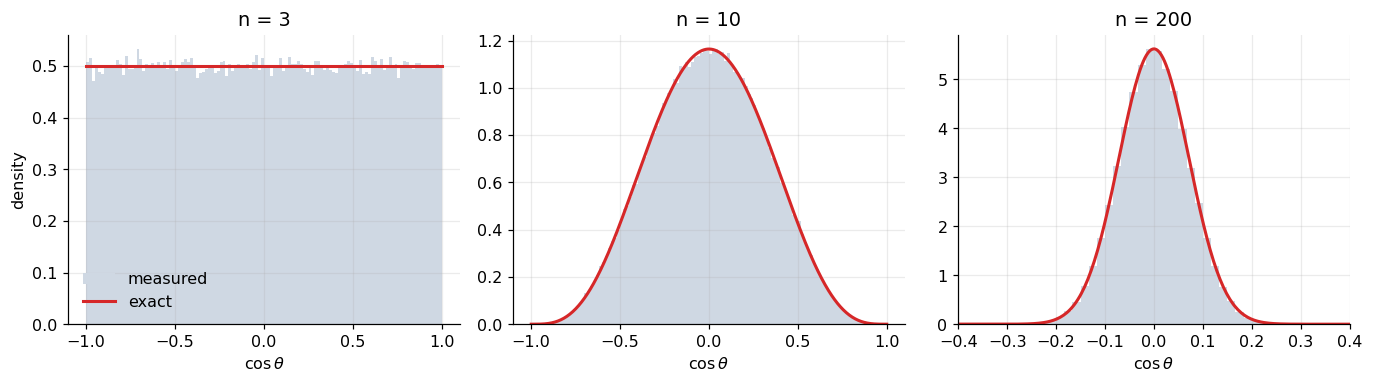

    n   exact E|cos|    measured   sqrt(2/pi n)  asympt. err
    2         0.6366      0.6359         0.5642       11.4%
    3         0.5000      0.5009         0.4607        7.9%
   10         0.2587      0.2588         0.2523        2.5%


   50         0.1134      0.1134         0.1128        0.5%


  200         0.0565      0.0566         0.0564        0.1%


  400         0.0399      0.0400         0.0399        0.1%

   exact closed forms:  n=2 -> 2/pi = 0.63662   n=3 -> 1/2 = 0.5

    n  theta    0.5*betainc(...)    integral of p(t)
    5     60        1.562500e-01        1.562500e-01
   20     60        1.049575e-02        1.049575e-02
  200     60        2.062078e-14        2.062078e-14

Fisher's r for N paired samples == cos(theta) in n = N-1 dimensions


   N=  5 -> n=  4:  measured E|r| = 0.4240,   exact E|cos| = 0.4244


   N=  8 -> n=  7:  measured E|r| = 0.3115,   exact E|cos| = 0.3125


   N= 20 -> n= 19:  measured E|r| = 0.1863,   exact E|cos| = 0.1855


In [12]:
# ---------------------------------------------------------------------------
# Appendix B: checking the closed form. Self-contained; takes a few seconds.
# ---------------------------------------------------------------------------
from scipy.special import gammaln, betainc, beta as Beta_fn
from scipy.integrate import quad

def p_cos(t, n):
    """Exact density of cos(theta) between two random directions in n dims."""
    return (1 - t**2)**((n - 3)/2) / Beta_fn(0.5, (n - 1)/2)

def E_abs_cos(n):
    """Exact E|cos(theta)| = 2 Gamma(n/2) / ((n-1) sqrt(pi) Gamma((n-1)/2)).

    gammaln is log(Gamma); using it and exponentiating avoids overflow, since
    Gamma(200) is far beyond the largest representable float.
    """
    return 2*np.exp(gammaln(n/2) - gammaln((n - 1)/2)) / ((n - 1)*np.sqrt(np.pi))

def sample_cos(n, K, rng):
    """K samples of cos(theta) between two independent random directions."""
    a = rng.standard_normal((K, n)); a /= np.linalg.norm(a, axis=1, keepdims=True)
    b = rng.standard_normal((K, n)); b /= np.linalg.norm(b, axis=1, keepdims=True)
    return np.sum(a*b, axis=1)                       # row-wise dot products

rng_ap = np.random.default_rng(0)

# ---- the money plot: measured histogram against the exact curve ------------
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.6))
for ax, n in zip(axes, (3, 10, 200)):
    t = sample_cos(n, 300_000, rng_ap)
    ax.hist(t, bins=np.linspace(-1, 1, 121), density=True, color="#cfd8e3",
            edgecolor="none", label="measured")
    tt = np.linspace(-0.999, 0.999, 600)
    ax.plot(tt, p_cos(tt, n), lw=2, color="#d62728", label="exact")
    ax.set(xlabel=r"$\cos\theta$", ylabel="density" if n == 3 else "",
           title=f"n = {n}")
    if n == 3: ax.legend()
    if n == 200: ax.set_xlim(-0.4, 0.4)     # zoom: the spike is very narrow
plt.tight_layout(); plt.show()

# ---- E|cos| : exact vs measured vs the large-n asymptotic ------------------
print(f"{'n':>5}{'exact E|cos|':>15}{'measured':>12}{'sqrt(2/pi n)':>15}{'asympt. err':>13}")
for n in (2, 3, 10, 50, 200, 400):
    mc = np.abs(sample_cos(n, 200_000, rng_ap)).mean()
    ex, asy = E_abs_cos(n), np.sqrt(2/(np.pi*n))
    print(f"{n:>5}{ex:>15.4f}{mc:>12.4f}{asy:>15.4f}{abs(asy/ex-1):>12.1%}")
print("\n   exact closed forms:  n=2 -> 2/pi =", round(2/np.pi, 6),
      "  n=3 -> 1/2 =", round(E_abs_cos(3), 6))

# ---- the cap fraction is just this density's tail --------------------------
print(f"\n{'n':>5}{'theta':>7}{'0.5*betainc(...)':>20}{'integral of p(t)':>20}")
for n in (5, 20, 200):
    th = np.pi/3                                     # 60 degrees
    cap = 0.5*betainc((n - 1)/2, 0.5, np.sin(th)**2)
    tail, _ = quad(p_cos, np.cos(th), 1, args=(n,), limit=200)
    print(f"{n:>5}{60:>7}{cap:>20.6e}{tail:>20.6e}")

# ---- Fisher 1915: the null distribution of the correlation coefficient -----
print("\nFisher's r for N paired samples == cos(theta) in n = N-1 dimensions")
for N in (5, 8, 20):
    r = []
    for _ in range(20_000):
        x = rng_ap.standard_normal(N); y = rng_ap.standard_normal(N)
        x -= x.mean(); y -= y.mean()                 # mean removal costs 1 dim
        r.append(x @ y / (np.linalg.norm(x)*np.linalg.norm(y)))
    r = np.array(r)
    n = N - 1
    # compare measured mean |r| with the exact formula at n = N-1
    print(f"   N={N:>3} -> n={n:>3}:  measured E|r| = {np.abs(r).mean():.4f},"
          f"   exact E|cos| = {E_abs_cos(n):.4f}")